### Demoblatt - SuS
--- 



# `Preprocessing` - Kategorien umwandeln


Kategoriale Daten sind Daten, die diskret sind und im Allgemeinen eine begrenzte Anzahl möglicher Werte annehmen, wie z. B. „Alter“, „Geschlecht“, „Land“ usw. 

Normalerweise besitzen kategorische Daten den Datentyp String. Das muss aber nicht immer der Fall sein. Zum Beispiel ist „Alter“, eine diskrete, kategoriale Variable mit dem Datentyp Integer.
Da die meisten Modelle nur numerische Werte verarbeiten können, müssen diese *`nominale Kategorien` in `numerische Kategorien`* umgewandelt werden. 

> ---
>
> *`Dies muss für ALLE INDEPENDEND Features durchgeführt werden, welche im Modell verwendet werden sollen.`*
>
> ---


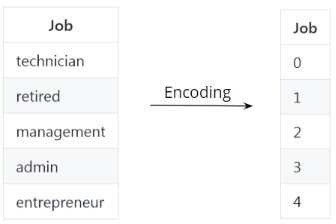
https://artemoppermann.com/de/data-preprocessing-in-machine-learning/

In [ ]:
from sklearn import preprocessing
import numpy as np

# Define some categorical string features
job=["technician", "retired", "management", "admin", "entrepreneur"]

# Import the encoder from sklearn
le = preprocessing.LabelEncoder()

# Encode the features
encoded_features=le.fit_transform(job)

# Print the result of the encoding process
print(encoded_features) # Result: [4, 3, 2, 0, 1]

An diesem Punkt könnte der Gedanke aufkommen: Alles erledigt, alle Strings sind durch numerische Werte ersetzt, Aufgabe erfüllt. Doch so einfach ist es leider nicht. Obwohl diese Werte in ein neuronales Netz eingespeist werden könnten, würde dies beim Training Probleme verursachen, da die Merkmale weiterhin kategorisch sind.

Das Problem liegt darin, dass den Zeichenkettenwerten `willkürlich numerische Werte zugewiesen wurden`. Diese Werte wurden in aufsteigender Reihenfolge entsprechend der Position der kategorischen String-Dateninstanz im Datensatz vergeben. 

**Folglich könnte das Modell während des Trainings höheren Zahlenwerten eine größere Bedeutung beimessen.**

In diesem speziellen Beispiel hat die Berufsbezeichnung „Unternehmer“ einen höheren numerischen Wert als „Admin“. Einige könnten im echten Leben argumentieren, dass der Beruf des Unternehmers tatsächlich höher angesehen wird. Bei der Ausbildung eines algorithmischen Modells ist dies jedoch nicht notwendig.

Vielmehr hängt es von dem zu lösenden Problem ab, ob die gegebene Berufsbezeichnung für dieses spezielle Problem von größerer Bedeutung ist oder nicht.


In [ ]:
from sklearn import preprocessing
import numpy as np

# Define some categorical string features
size=["x-small", "small", "medium", "large", "x-large"]

# Import the encoder from sklearn
le = preprocessing.LabelEncoder()

# Encode the features
encoded_features=le.fit_transform(size)

# Print the result of the encoding process
print(encoded_features) # Result: [4, 2, 1, 0, 3]

Kleidergrößen besitzen, obwohl sie kategorische Daten sind, auch eine Reihenfolge, welche ihrer Größe entspricht.

`large` wurde in diesem Beispiel der nummerische Wert `0` zugeordnet, `small` der Wert `2`.
Dadurch ging bei der Umwandlung jedoch die Reihenfolge verloren. 

> ---
> 
> *`Falls die Reihenfolge für die Daten wichtig ist, muss bei der Konvertierung darauf geachtet werden, dass diese Information nicht verloren geht und die nummerischen Werte der Größe nach zugeordnet werden.`*
>
> ---

---
# Beispiel - `Medikamenten Bestimmung`


In [ ]:
from sklearn.datasets import fetch_openml
import pandas as pd

#-------------------------------------------------------------------------
# Laden der Daten
drug = fetch_openml(name='Drug-Classification', data_home='./data')
#print(drug.details)

dfDrugs = drug.data

# Ersten Zeilen ausgeben
dfDrugs.head()

Ermitteln welche Kategorien bei jeder kategorischen Variable vorhanden sind.

In [ ]:
print('\n', dfDrugs['BP'].value_counts())
print('\n', dfDrugs['Sex'].value_counts())
print('\n', dfDrugs['Cholesterol'].value_counts())
print('\n', dfDrugs['Drug'].value_counts())

---
## 🔷 1. Umwandeln mit `MAP`
Mit der `map()`-Methode kann jeder Wert eines Features durch einen anderen Wert ersetzt werden.<br>
Das ist eine einfache Möglichkeit jeder Kategorie einen bestimmten Wert zuzuordnen. 

Ein Nachteil ist, das sich der Programmierer um weitere Konvertierungen selbst kümmern und dabei die Zuordnung überall gleich einhalten muss.

In [ ]:
# Verwendung der map-Funktion, um die Werte der 'Drug' Spalte direkt in numerische Werte zu konvertieren.
# Die Zuordnung wird durch ein Dictionary definiert, das kategoriale Labels auf numerische Werte abbildet.
dfDrugs['DrugNumMap'] = dfDrugs['Drug'].map({
    'DrugY': 0,  # 'DrugY' wird zu 0
    'drugX': 1,  # 'drugX' wird zu 1
    'drugA': 2,  # 'drugA' wird zu 2
    'drugB': 3,  # 'drugB' wird zu 3
    'drugC': 4   # 'drugC' wird zu 4
})

# Anzeige der ersten Zeilen des DataFrame, um zu überprüfen, ob die Zuordnung korrekt durchgeführt wurde.
dfDrugs.head()
        

## 🔷 2. Umwandeln mit `LabelEncoder`
Der Labelencoder bietet eine einfache Möglichkeit, alle Kategorien eines Features in nummerische Werte umzuwandeln.
Die getroffene Zuordnung bleibt im Encoder erhalten und kann für weitere Konvertierungen verwendet werden.

In [ ]:
from sklearn import preprocessing

# Initialisierung des LabelEncoders für die Spalte 'Drug'.
le_Drug = preprocessing.LabelEncoder()

# Anpassung des LabelEncoders an die Daten in der Spalte 'Drug'.
# Dieser Schritt ermittelt alle einzigartigen Kategorien in der Spalte 'Drug' und ordnet jeder Kategorie eine Ganzzahl zu.
le_Drug.fit(dfDrugs['Drug'])

# Transformation der kategorialen Werte in der Spalte 'Drug' zu ihren entsprechenden numerischen Indizes.
# Diese numerischen Werte werden in einer neuen Spalte 'DrugNumLE' im DataFrame dfDrugs gespeichert.
dfDrugs['DrugNumLE'] = le_Drug.transform(dfDrugs['Drug'])

# Anzeige der ersten 5 Zeilen des DataFrame, um die Originaldaten und die transformierten numerischen Werte zu überprüfen.
dfDrugs.head(5)

#### Kategorien zurückkonvertieren
Mit dem erstellten LabelEncoder können nicht nur weitere Werte dieser Kategorie konvertiert werden, sondern auch die nummerischen Werte wieder zurück konvertiert werden.


In [ ]:
# Eine Schleife, die für jeden Wert von 0 bis 2 (einschließlich) läuft.
for num in range(0, 3):
    # Hier wird der inverse_transform Methode des LabelEncoders le_Drug verwendet,
    # um die numerischen Werte zurück in die ursprünglichen kategorialen Werte umzuwandeln.
    # Die Ausgabe zeigt die Medikamentennamen, die den entsprechenden numerischen Werten zugeordnet sind.
    print("Medikament: ", num, ' --> ', le_Drug.inverse_transform([num]))

# Anwendung der inverse_transform Methode auf die gesamte Spalte 'DrugNumLE' des DataFrame dfDrugs.
# Dies konvertiert alle numerischen Werte in der Spalte zurück in ihre ursprünglichen kategorialen Labels.
dfDrugs['DrugInverse'] = le_Drug.inverse_transform(dfDrugs['DrugNumLE'])

# Anzeige der ersten 5 Zeilen des DataFrame, um die neuen und alten Werte zu überprüfen.
dfDrugs.head(5)


#### Umwandeln aller kategorischen Feature
Für die meisten Modelle müssen alle kategorischen Feature in nummerische Werte umgewandelt werden.  
In unserem Beispiel müssen also auch die Feature BP, Sex und Cholesterol umgewandelt werden.

In [ ]:
from sklearn import preprocessing

# Initialisierung der LabelEncoder Objekte für die drei unterschiedlichen Features.
le_Sex = preprocessing.LabelEncoder()
le_BP = preprocessing.LabelEncoder()
le_Cholesterol = preprocessing.LabelEncoder()

# -----------------------------------------------------------------------
# Transformation der kategorialen Werte der Spalten 'BP', 'Sex' und 'Cholesterol' in numerische Werte.
# Dabei wird jeder kategoriale Wert in eine eindeutige Ganzzahl umgewandelt, beginnend bei 0.
# -----------------------------------------------------------------------
# ---> Dein Code

# 'BP' wird umgewandelt und die numerischen Werte in 'BPLE' gespeichert.
dfDrugs['BPLE'] = "Dein Code"   

# 'Sex' wird umgewandelt und die numerischen Werte in 'SexLE' gespeichert.
dfDrugs['SexLE'] = "Dein Code"  

# 'Cholesterol' wird umgewandelt und die numerischen Werte in 'CholesterolLE' gespeichert.
dfDrugs['CholesterolLE'] = "Dein Code"  


# -----------------------------------------------------------------------
# Anzeige der ersten 10 Zeilen der relevanten Spalten im DataFrame,
# um die Originaldaten und die transformierten Daten zu vergleichen.
dfDrugs[['Sex', 'SexLE', 'BP', 'BPLE', 'Cholesterol', 'CholesterolLE']].head(10)


## 🔷 4. Umwandeln mit `OrdinalEncoder`
Um mehrere Feature gleichzeitig umzuwandeln und nicht für jedes Feature einen eigenen LabelEncoder erstellen zu müssen, kann der OrdinalEncoder verwendet werden.

`Dieser hat die gleiche Funktion wie der LabelEncoder, verarbeitet jedoch mehrere Features gleichzeitig.`

In [ ]:
from sklearn import preprocessing

# Erstellung eines OrdinalEncoder Objekts ohne spezifische Kategorien.
# Das bedeutet, der Encoder wird automatisch die Kategorien aus den Daten erkennen
# und sie in eine numerische Reihenfolge bringen, beginnend bei 0.
oe_Drugs = preprocessing.OrdinalEncoder()

# Anpassung des Encoders an die Daten. Hier werden die Spalten 'Sex', 'BP' und 'Cholesterol' aus dem DataFrame dfDrugs verwendet.
# Der Encoder wird die einzigartigen Kategorien in jeder Spalte erkennen und ihnen aufsteigende Zahlen zuweisen.
oe_Drugs.fit(dfDrugs[['Sex', 'BP', 'Cholesterol']])

# Transformation der kategorialen Daten in numerische Werte.
# Die transformierten Daten werden in neuen Spalten 'SexOE', 'BPOE', 'CholesterolOE' gespeichert.
dfDrugs[['SexOE', 'BPOE', 'CholesterolOE']] = oe_Drugs.transform(dfDrugs[['Sex', 'BP', 'Cholesterol']])

# Anzeige der ersten 10 Zeilen der relevanten Spalten im DataFrame,
# um die Originaldaten und die transformierten Daten zu vergleichen.
dfDrugs[['Sex', 'SexLE', 'SexOE', 'BP', 'BPLE', 'BPOE', 'Cholesterol', 'CholesterolLE', 'CholesterolOE']].head(10)


---
## 🔷 5. Kategorien `MIT Reihenfolge` (Sortierung) umwandeln

Sind die Kategorien sortierbar (besitzen sie eine Reihenfolge zB. S,M,L,XL) so sollte die nummerische Kodierung auch mit dieser Reihenfolge erstellt werden.

### 5.1 Umwandeln mit `MAP`
Da bei der map()-Methode die nummerischen Ersatzwerte angegeben werden müssen, kann dabei auch die Reihenfolge festgelegt werden.  
Der Programmierer muss allerdings überall darauf achten, die entsprechende Zuordnung zu verwenden.

In [ ]:
# Anwendung der map-Funktion auf die 'BP' Spalte im DataFrame dfDrugs.
# Diese Funktion weist jedem eindeutigen kategorialen Wert einen spezifischen numerischen Wert zu.
dfDrugs['BPMap'] = dfDrugs['BP'].map({
    'LOW': 10,    # 'LOW' wird zu 10
    'NORMAL': 20, # 'NORMAL' wird zu 20
    'HIGH': 30    # 'HIGH' wird zu 30
})

# Anzeige der Spalten 'BP', 'BPLE', und 'BPMap' der ersten Zeilen des DataFrame,
# um die originalen kategorialen Werte, die durch LabelEncoder transformierten Werte und
# die durch map transformierten Werte zu vergleichen.
dfDrugs[['BP', 'BPLE', 'BPMap']].head()

        

### 5.2 Umwandeln mit `OrdinalEncoder`
Allerdings gibt es auch die Möglichkeit beim OrdinalEncoder die Reihenfolge der Kategorien festzulegen und gleichzeitig mehrere Feature umzuwandeln. 

In [ ]:
from sklearn import preprocessing

# Initialisierung des OrdinalEncoder mit spezifischen Kategorien.
# 'Sex' wird kodiert als: 'F' -> 0, 'M' -> 1
# 'BP' (Blutdruck) wird kodiert als: 'LOW' -> 0, 'NORMAL' -> 1, 'HIGH' -> 2
# 'Cholesterol' wird kodiert als: 'NORMAL' -> 0, 'HIGH' -> 1
oe_Drugs = preprocessing.OrdinalEncoder(categories=[['F', 'M'],                 # Sex    
                                                    ['LOW', 'NORMAL', 'HIGH'],  # BP
                                                    ['NORMAL', 'HIGH']])        # Cholesterol

# Anpassung des Encoders auf die Daten. Hier werden die Spalten 'Sex', 'BP' und 'Cholesterol' aus dem DataFrame dfDrugs verwendet.
oe_Drugs.fit(dfDrugs[['Sex', 'BP', 'Cholesterol']])

# Transformation der kategorialen Daten in numerische Werte.
# Die transformierten Daten werden in neuen Spalten 'SexOEr', 'BPOEr', 'CholesterolOEr' gespeichert.
dfDrugs[['SexOEr', 'BPOEr', 'CholesterolOEr']] = oe_Drugs.transform(dfDrugs[['Sex', 'BP', 'Cholesterol']])

# Anzeige der ersten 20 Zeilen der relevanten Spalten im DataFrame,
# um die Originaldaten und die transformierten Daten zu vergleichen.
dfDrugs[['Sex','SexOE','SexOEr','BP','BPOE','BPOEr', 'Cholesterol','CholesterolOE','CholesterolOEr']].head(20)

